### Cell 1 — Install Dependencies

In [15]:
# Cell 01: Install dependencies
!pip install numpy pandas matplotlib seaborn scikit-learn tensorflow wordcloud nltk -q
!pip install gensim -q

### Cell 2 — Imports

In [ ]:
# Cell 02: Imports
import re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

warnings.filterwarnings('ignore')
print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU')}")

### Cell 3 — Load Dataset

In [ ]:
# Cell 03: Load dataset
from google.colab import drive
drive.mount('/content/drive')

# ── UPDATE THIS PATH TO WHERE YOU UPLOADED THE CSV ──
CSV_PATH = "/content/drive/MyDrive/AI-ML/Coursework/Text Classification/Book Review Dataset/Book_review.csv"
# ────────────────────────────────────────────────────

df = pd.read_csv(CSV_PATH)
df = df[['rating', 'reviewText']].dropna().reset_index(drop=True)

print(f"Shape        : {df.shape}")
print(f"Columns      : {df.columns.tolist()}")
print(f"Rating range : {df['rating'].min()} – {df['rating'].max()}")
print(f"Nulls        : {df.isnull().sum().to_dict()}")
df.head()

### OR if uploading zip directly:

In [ ]:
# #Upload zip directly (alternative to Drive)
# from google.colab import files
# import zipfile, io

# uploaded = files.upload()
# zip_name = list(uploaded.keys())[0]
# with zipfile.ZipFile(io.BytesIO(uploaded[zip_name])) as z:
#     csv_name = [f for f in z.namelist() if f.endswith('.csv')][0]
#     with z.open(csv_name) as f:
#         df = pd.read_csv(f)

# df = df[['rating', 'reviewText']].dropna().reset_index(drop=True)
# print(f"Shape : {df.shape}")
# print(df['rating'].value_counts().sort_index())

### Cell 4 — Map Ratings to Sentiment Labels

In [ ]:
# Cell 04: Map 1-5 ratings → 3 sentiment classes

def map_sentiment(rating):
    if rating <= 2:  return 0   # Negative
    elif rating == 3: return 1  # Neutral
    else:             return 2  # Positive

df['sentiment'] = df['rating'].apply(map_sentiment)
label_names = ['Negative', 'Neutral', 'Positive']

print("Sentiment distribution:")
print(df['sentiment'].value_counts().sort_index()
      .rename({0:'Negative', 1:'Neutral', 2:'Positive'}))

# Visualise class distribution
colors = ['#e74c3c', '#f39c12', '#2ecc71']
counts = df['sentiment'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(label_names, counts.values, color=colors, edgecolor='black')
axes[0].set_title("Sentiment Class Distribution", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Sentiment"); axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=label_names, autopct='%1.1f%%',
            colors=colors, startangle=140)
axes[1].set_title("Sentiment Proportion", fontsize=13, fontweight='bold')

plt.suptitle(f"Total reviews: {len(df):,}", fontsize=11, color='gray')
plt.tight_layout()
plt.savefig("01_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

### Cell 5 — Text Cleaning & Preprocessing

In [ ]:
# Cell 05: Text cleaning pipeline
STOPWORDS  = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

CONTRACTIONS = {
    "don't":"do not", "won't":"will not", "can't":"cannot",
    "isn't":"is not", "aren't":"are not", "wasn't":"was not",
    "weren't":"were not", "haven't":"have not", "hasn't":"has not",
    "hadn't":"had not", "wouldn't":"would not", "couldn't":"could not",
    "shouldn't":"should not", "i'm":"i am", "i've":"i have",
    "i'll":"i will", "i'd":"i would", "you're":"you are",
    "you've":"you have", "they're":"they are", "it's":"it is",
    "that's":"that is", "what's":"what is", "there's":"there is"
}

def clean_text(text):
    text = str(text).lower()                                  # lowercase
    for word, replacement in CONTRACTIONS.items():            # contractions
        text = text.replace(word, replacement)
    text = re.sub(r'http\S+|www\S+',        '', text)        # remove URLs
    text = re.sub(r'@\w+',                  '', text)        # remove mentions
    text = re.sub(r'#\w+',                  '', text)        # remove hashtags
    text = re.sub(r'\d+',                   '', text)        # remove numbers
    text = re.sub(r'[^a-z\s]',             '', text)        # remove special chars
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens        # lemmatize
              if w not in STOPWORDS and len(w) > 2]          # remove stopwords
    return ' '.join(tokens)

print("Cleaning text... (may take ~30 seconds)")
start = time.time()
df['clean_text'] = df['reviewText'].apply(clean_text)
print(f"Done in {time.time()-start:.1f}s")

# Show before/after
print("\nBEFORE:", df['reviewText'].iloc[1][:150])
print("AFTER :", df['clean_text'].iloc[1][:150])

### Cell 6 — Visualize Clean Text

In [ ]:
# Cell 06: Visualize cleaned text

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (label, color) in enumerate(zip(label_names, ['Reds', 'Oranges', 'Greens'])):
    subset = df[df['sentiment'] == i]['clean_text']
    text   = ' '.join(subset)
    wc     = WordCloud(width=500, height=300, background_color='white',
                       colormap=color, max_words=80).generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f"{label} Reviews", fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.suptitle("Word Clouds by Sentiment Class", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("02_wordclouds.png", dpi=150, bbox_inches='tight')
plt.show()

# Top 15 words per class
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (label, color) in enumerate(zip(label_names, ['#e74c3c', '#f39c12', '#2ecc71'])):
    all_words = ' '.join(df[df['sentiment'] == i]['clean_text']).split()
    top15     = Counter(all_words).most_common(15)
    words, counts = zip(*top15)
    axes[i].barh(words[::-1], counts[::-1], color=color)
    axes[i].set_title(f"Top Words — {label}", fontweight='bold')
    axes[i].set_xlabel("Frequency")

plt.suptitle("Top 15 Words per Sentiment Class", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("03_top_words.png", dpi=150, bbox_inches='tight')
plt.show()

### Cell 7 — Tokenization & Padding

In [ ]:
# Cell 07: Tokenization and padding

VOCAB_SIZE  = 10000
MAX_LEN     = None   # will be set by percentile below
EMBED_DIM   = 64
TEST_SIZE   = 0.20
SEED        = 42

texts  = df['clean_text'].values
labels = df['sentiment'].values

# 80/20 train/test split
X_train_text, X_test_text, y_train, y_test = train_test_split(
    texts, labels, test_size=TEST_SIZE, random_state=SEED, stratify=labels
)

# Tokenize
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text)
word_index = tokenizer.word_index

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq  = tokenizer.texts_to_sequences(X_test_text)

# Percentile-based padding length (95th percentile avoids outlier-length sequences)
lengths = [len(s) for s in X_train_seq]
MAX_LEN = int(np.percentile(lengths, 95))
print(f"Vocab size       : {min(VOCAB_SIZE, len(word_index)):,}")
print(f"Sequence lengths : mean={np.mean(lengths):.0f}, "
      f"median={np.median(lengths):.0f}, 95th pct={MAX_LEN}")

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

# One-hot encode labels for categorical_crossentropy
y_train_cat = keras.utils.to_categorical(y_train, num_classes=3)
y_test_cat  = keras.utils.to_categorical(y_test,  num_classes=3)

print(f"\nTrain shape : {X_train_pad.shape}")
print(f"Test  shape : {X_test_pad.shape}")
print(f"MAX_LEN     : {MAX_LEN}")

# Plot sequence length distribution
plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=50, color='#3498db', edgecolor='black', alpha=0.8)
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'95th pct = {MAX_LEN}')
plt.title("Review Length Distribution (after cleaning)", fontweight='bold')
plt.xlabel("Number of tokens"); plt.ylabel("Count")
plt.legend(); plt.tight_layout()
plt.savefig("04_seq_lengths.png", dpi=150, bbox_inches='tight')
plt.show()

### Cell 8 — Training Utilities

In [ ]:
# Cell 08: Shared training utilities

def plot_history(history, title, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(history.history['loss'],     label='Train', color='#e74c3c', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val',   color='#3498db', linewidth=2)
    axes[0].set_title(f"{title} — Loss",     fontweight='bold')
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['accuracy'],     label='Train', color='#e74c3c', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Val',   color='#3498db', linewidth=2)
    axes[1].set_title(f"{title} — Accuracy", fontweight='bold')
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def evaluate_model(model, X, y_cat, y_true, label_names, title, save_path=None):
    loss, acc = model.evaluate(X, y_cat, verbose=0)
    print(f"  Loss     : {loss:.4f}")
    print(f"  Accuracy : {acc*100:.2f}%\n")

    y_pred = np.argmax(model.predict(X, verbose=0), axis=1)
    print(classification_report(y_true, y_pred, target_names=label_names, digits=4))

    cm  = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, ax=ax)
    ax.set_title(f"Confusion Matrix — {title}", fontweight='bold')
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return loss, acc, y_pred


class PrintEvery5(keras.callbacks.Callback):
    def __init__(self, total_epochs):
        self.total = total_epochs
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{self.total} | "
                  f"loss: {logs['loss']:.4f}  acc: {logs['accuracy']*100:.2f}% | "
                  f"val_loss: {logs['val_loss']:.4f}  val_acc: {logs['val_accuracy']*100:.2f}%")

print("Utilities ready.")

### Cell 9 — Model 1: Simple RNN

In [ ]:
# Cell 09: Model 1 — Simple RNN with trainable Embedding

EPOCHS = 20

def build_rnn(vocab_size, embed_dim, max_len, num_classes=3):
    model = keras.Sequential([
        layers.Embedding(input_dim=vocab_size, output_dim=embed_dim,
                         input_length=max_len, name='embedding'),
        layers.SimpleRNN(64, return_sequences=False, name='simple_rnn'),
        layers.Dropout(0.4),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name="Simple_RNN")
    return model

model1 = build_rnn(VOCAB_SIZE, EMBED_DIM, MAX_LEN)
model1.summary()

model1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n" + "="*55)
print("TRAINING: Model 1 — Simple RNN")
print("="*55)

start = time.time()
history1 = model1.fit(
    X_train_pad, y_train_cat,
    epochs=EPOCHS,
    batch_size=64,
    validation_split=0.15,
    callbacks=[
        PrintEvery5(EPOCHS),
        keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True, monitor='val_accuracy'),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=0)
    ],
    verbose=0
)
time1 = time.time() - start
print(f"\nTraining time : {time1:.1f}s | Best val_acc: {max(history1.history['val_accuracy'])*100:.2f}%")
plot_history(history1, "Model 1 — Simple RNN", save_path="05_rnn_curves.png")

### Cell 10 — Model 2: LSTM

In [ ]:
# Cell 10: Model 2 — LSTM with trainable Embedding

def build_lstm(vocab_size, embed_dim, max_len, num_classes=3):
    model = keras.Sequential([
        layers.Embedding(input_dim=vocab_size, output_dim=embed_dim,
                         input_length=max_len, name='embedding'),
        layers.LSTM(64, return_sequences=True,  name='lstm_1'),
        layers.Dropout(0.3),
        layers.LSTM(32, return_sequences=False, name='lstm_2'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name="LSTM_Trainable_Embedding")
    return model

model2 = build_lstm(VOCAB_SIZE, EMBED_DIM, MAX_LEN)
model2.summary()

model2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n" + "="*55)
print("TRAINING: Model 2 — LSTM")
print("="*55)

start = time.time()
history2 = model2.fit(
    X_train_pad, y_train_cat,
    epochs=EPOCHS,
    batch_size=64,
    validation_split=0.15,
    callbacks=[
        PrintEvery5(EPOCHS),
        keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True, monitor='val_accuracy'),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=0)
    ],
    verbose=0
)
time2 = time.time() - start
print(f"\nTraining time : {time2:.1f}s | Best val_acc: {max(history2.history['val_accuracy'])*100:.2f}%")
plot_history(history2, "Model 2 — LSTM", save_path="06_lstm_curves.png")

### Cell 11 — Model 3: LSTM + GloVe Word2Vec

This may take 2-3 minutes on first run...
[==================================================] 100.0% 66.0/66.0MB downloaded
Downloaded!
Words found in GloVe : 9,405 / 10,000


Model: "LSTM_GloVe_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,000 (1.91 MB)


TRAINING: Model 3 — LSTM + GloVe Word2Vec
  Epoch   1/20 | loss: 1.0267  acc: 49.51% | val_loss: 1.0047  val_acc: 50.56%
  Epoch   5/20 | loss: 1.0106  acc: 50.12% | val_loss: 1.0054  val_acc: 50.69%
  Epoch  10/20 | loss: 0.9995  acc: 52.13% | val_loss: 0.9928  val_acc: 52.43%

Training time : 473.3s | Best val_acc: 52.71%


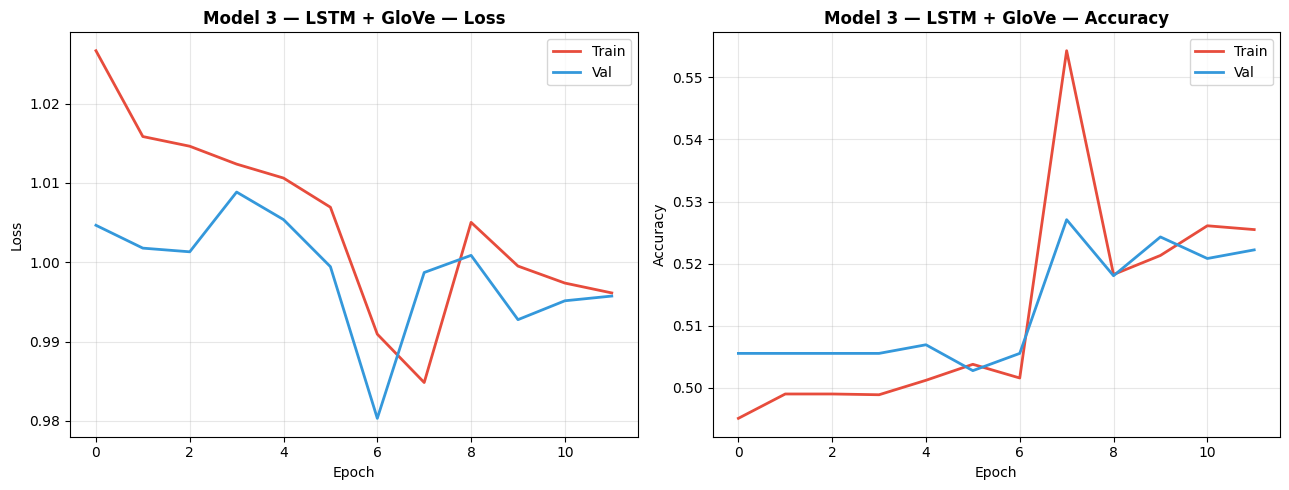

In [14]:
# Cell 11: Model 3 — LSTM with pretrained GloVe embeddings
import gensim.downloader as api

print("Downloading GloVe embeddings (glove-wiki-gigaword-50)...")
print("This may take 2-3 minutes on first run...")
embedding_model = api.load('glove-wiki-gigaword-50')   # 50-dimensional
print("Downloaded!")

EMBED_DIM_W2V = 50

# Build embedding matrix
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM_W2V))
found = 0
for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[idx] = embedding_model[word]
        found += 1

print(f"Words found in GloVe : {found:,} / {min(VOCAB_SIZE, len(word_index)):,}")

def build_lstm_w2v(vocab_size, embed_dim, embed_matrix, max_len, num_classes=3):
    model = keras.Sequential([
        layers.Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim,
            weights=[embed_matrix],
            input_length=max_len,
            trainable=False,           # frozen — use GloVe as-is
            name='glove_embedding'
        ),
        layers.LSTM(64, return_sequences=True,  name='lstm_1'),
        layers.Dropout(0.3),
        layers.LSTM(32, return_sequences=False, name='lstm_2'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name="LSTM_GloVe_Embedding")
    return model

model3 = build_lstm_w2v(VOCAB_SIZE, EMBED_DIM_W2V, embedding_matrix, MAX_LEN)
model3.summary()

model3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n" + "="*55)
print("TRAINING: Model 3 — LSTM + GloVe Word2Vec")
print("="*55)

start = time.time()
history3 = model3.fit(
    X_train_pad, y_train_cat,
    epochs=EPOCHS,
    batch_size=64,
    validation_split=0.15,
    callbacks=[
        PrintEvery5(EPOCHS),
        keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True, monitor='val_accuracy'),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=0)
    ],
    verbose=0
)
time3 = time.time() - start
print(f"\nTraining time : {time3:.1f}s | Best val_acc: {max(history3.history['val_accuracy'])*100:.2f}%")
plot_history(history3, "Model 3 — LSTM + GloVe", save_path="07_lstm_w2v_curves.png")

### Cell 12 — Evaluate All 3 Models

-------------------------------------------------------
MODEL 1 — Simple RNN
-------------------------------------------------------
  Loss     : 1.0151
  Accuracy : 50.00%

              precision    recall  f1-score   support

    Negative     0.0000    0.0000    0.0000       800
     Neutral     0.0000    0.0000    0.0000       400
    Positive     0.5000    1.0000    0.6667      1200

    accuracy                         0.5000      2400
   macro avg     0.1667    0.3333    0.2222      2400
weighted avg     0.2500    0.5000    0.3333      2400



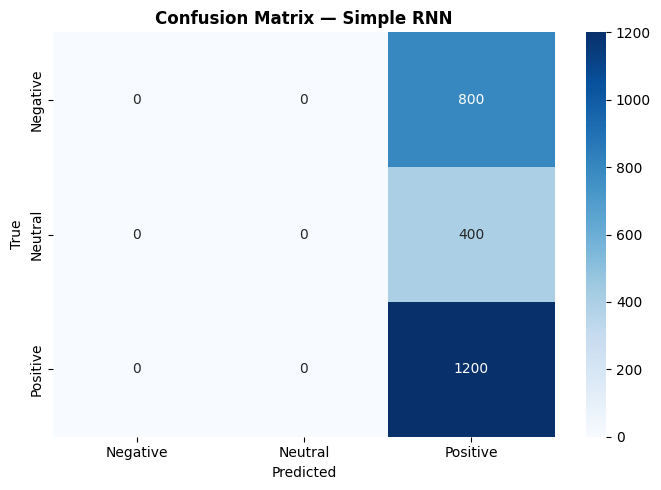

-------------------------------------------------------
MODEL 2 — LSTM
-------------------------------------------------------
  Loss     : 1.0255
  Accuracy : 49.96%

              precision    recall  f1-score   support

    Negative     0.5000    0.0013    0.0025       800
     Neutral     0.2500    0.0025    0.0050       400
    Positive     0.5000    0.9975    0.6661      1200

    accuracy                         0.4996      2400
   macro avg     0.4167    0.3337    0.2245      2400
weighted avg     0.4583    0.4996    0.3347      2400



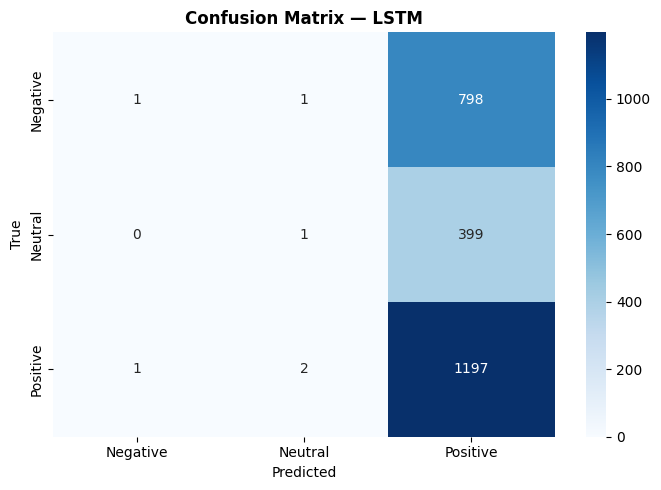

-------------------------------------------------------
MODEL 3 — LSTM + GloVe
-------------------------------------------------------
  Loss     : 0.9939
  Accuracy : 53.96%

              precision    recall  f1-score   support

    Negative     0.6952    0.1625    0.2634       800
     Neutral     0.0000    0.0000    0.0000       400
    Positive     0.5264    0.9708    0.6827      1200

    accuracy                         0.5396      2400
   macro avg     0.4072    0.3778    0.3154      2400
weighted avg     0.4949    0.5396    0.4292      2400



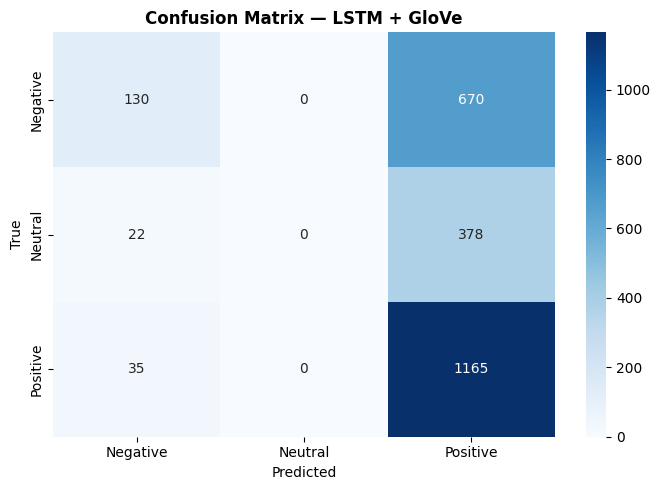

In [16]:
# Cell 12: Evaluate all models on test set

print("-"*55 + "\nMODEL 1 — Simple RNN\n" + "-"*55)
loss1, acc1, pred1 = evaluate_model(
    model1, X_test_pad, y_test_cat, y_test, label_names,
    "Simple RNN", save_path="08_rnn_cm.png"
)

print("-"*55 + "\nMODEL 2 — LSTM\n" + "-"*55)
loss2, acc2, pred2 = evaluate_model(
    model2, X_test_pad, y_test_cat, y_test, label_names,
    "LSTM", save_path="09_lstm_cm.png"
)

print("-"*55 + "\nMODEL 3 — LSTM + GloVe\n" + "-"*55)
loss3, acc3, pred3 = evaluate_model(
    model3, X_test_pad, y_test_cat, y_test, label_names,
    "LSTM + GloVe", save_path="10_lstm_w2v_cm.png"
)

### Cell 13 — Comparison Chart

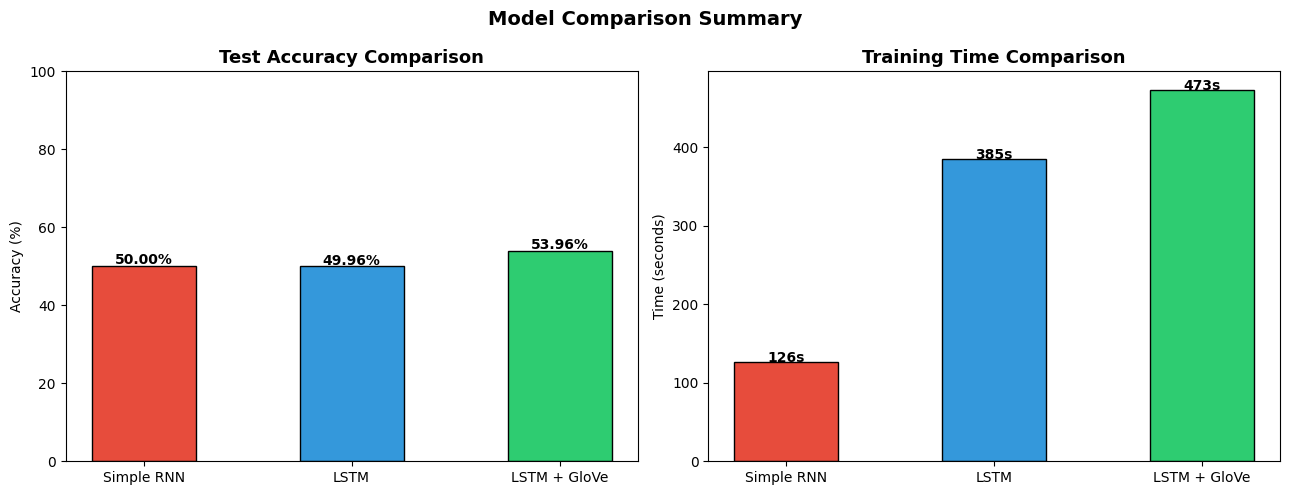

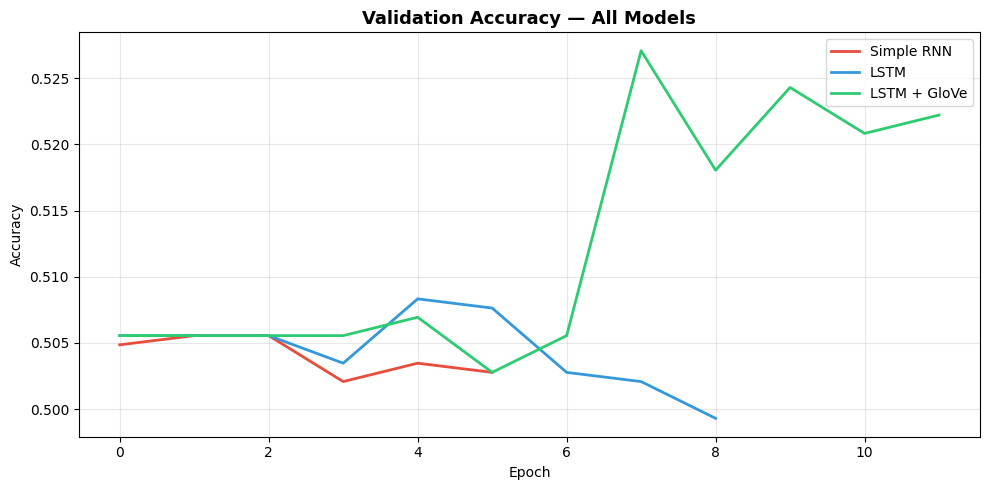


FINAL SUMMARY
  Simple RNN           Acc: 50.00%   Time: 126s
  LSTM                 Acc: 49.96%   Time: 385s
  LSTM + GloVe         Acc: 53.96%   Time: 473s


In [17]:
# Cell 13: Side-by-side model comparison

model_names = ['Simple RNN', 'LSTM', 'LSTM + GloVe']
accuracies  = [acc1*100, acc2*100, acc3*100]
train_times = [time1, time2, time3]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#e74c3c', '#3498db', '#2ecc71']
bars = axes[0].bar(model_names, accuracies, color=colors, edgecolor='black', width=0.5)
axes[0].set_title("Test Accuracy Comparison", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Accuracy (%)"); axes[0].set_ylim(0, 100)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5, f"{acc:.2f}%", ha='center', fontweight='bold')

axes[1].bar(model_names, train_times, color=colors, edgecolor='black', width=0.5)
axes[1].set_title("Training Time Comparison", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Time (seconds)")
for i, t in enumerate(train_times):
    axes[1].text(i, t + 0.5, f"{t:.0f}s", ha='center', fontweight='bold')

plt.suptitle("Model Comparison Summary", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("11_model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# Overlay training curves
plt.figure(figsize=(10, 5))
for h, name, color in zip([history1, history2, history3], model_names, colors):
    plt.plot(h.history['val_accuracy'], label=name, color=color, linewidth=2)
plt.title("Validation Accuracy — All Models", fontsize=13, fontweight='bold')
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("12_val_acc_overlay.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*55)
print("FINAL SUMMARY")
print("="*55)
for name, acc, t in zip(model_names, accuracies, train_times):
    print(f"  {name:<20} Acc: {acc:.2f}%   Time: {t:.0f}s")

### Cell 14 — Error Analysis

In [18]:
# Cell 14: Error analysis — misclassified examples

def show_errors(model, X_pad, texts, y_true, label_names, n=5, title=""):
    y_pred = np.argmax(model.predict(X_pad, verbose=0), axis=1)
    wrong  = np.where(y_pred != y_true)[0]
    print(f"{title} — {len(wrong)} misclassified out of {len(y_true)}\n")
    print(f"{'True':<12} {'Predicted':<12} Review (first 120 chars)")
    print("-" * 80)
    for i in wrong[:n]:
        print(f"{label_names[y_true[i]]:<12} {label_names[y_pred[i]]:<12} {texts[i][:120]}")
    print()

print("="*55 + "\nERROR ANALYSIS\n" + "="*55)
show_errors(model1, X_test_pad, X_test_text, y_test, label_names, n=3, title="Simple RNN")
show_errors(model2, X_test_pad, X_test_text, y_test, label_names, n=3, title="LSTM")
show_errors(model3, X_test_pad, X_test_text, y_test, label_names, n=3, title="LSTM + GloVe")

print("""
Possible reasons for errors:
1. Neutral class (rating=3) is ambiguous — reviews often mix praise and criticism.
2. Sarcasm is not captured by bag-of-words style embeddings.
3. Short reviews lack enough context for the model to decide confidently.
4. OOV (out-of-vocabulary) words map to zeros, losing meaning.
""")

ERROR ANALYSIS
Simple RNN — 1200 misclassified out of 2400

True         Predicted    Review (first 120 chars)
--------------------------------------------------------------------------------
Neutral      Positive     nice romance two mature adult short point predictable would like background two character even daughter real character d
Negative     Positive     thought positive review would love book book horrible start fast literally love one man morning love another evening pre
Negative     Positive     short sweet good short story lot sex like type book good read

LSTM — 1201 misclassified out of 2400

True         Predicted    Review (first 120 chars)
--------------------------------------------------------------------------------
Neutral      Positive     nice romance two mature adult short point predictable would like background two character even daughter real character d
Negative     Positive     thought positive review would love book book horrible start fast literally love o

### Cell 15 — Gradio GUI (Real-Time Prediction)

In [19]:
# Cell 15: Real-time prediction GUI with Gradio
!pip install gradio -q

import gradio as gr

def predict_sentiment(review_text):
    cleaned = clean_text(review_text)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    probs1 = model1.predict(padded, verbose=0)[0]
    probs2 = model2.predict(padded, verbose=0)[0]
    probs3 = model3.predict(padded, verbose=0)[0]

    def fmt(probs):
        idx = np.argmax(probs)
        return f"{label_names[idx]} ({probs[idx]*100:.1f}%)"

    return fmt(probs1), fmt(probs2), fmt(probs3)

demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=4, placeholder="Paste a book review here...", label="Book Review"),
    outputs=[
        gr.Textbox(label="Simple RNN Prediction"),
        gr.Textbox(label="LSTM Prediction"),
        gr.Textbox(label="LSTM + GloVe Prediction"),
    ],
    title="📚 Book Review Sentiment Analyser",
    description="Enter a book review and compare predictions from all 3 models.",
    examples=[
        ["This book was absolutely amazing, I couldn't put it down!"],
        ["Terrible waste of time. Boring and poorly written."],
        ["It was okay, nothing special but not bad either."]
    ]
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://48869805d1b512d145.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
